In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv("Netflix.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [5]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
7782,s995,TV Show,Blown Away,NaN,NaN,Canada,12-Jul-19,2019,TV-14,1,"International TV Shows, Reality TV",Ten master artists turn up the heat in glassbl...
7783,s996,TV Show,Blue Exorcist,NaN,"Nobuhiko Okamoto, Jun Fukuyama, Kana Hanazawa,...",Japan,1-Sep-20,2017,TV-MA,2,"Anime Series, International TV Shows",Determined to throw off the curse of being Sat...
7784,s997,Movie,Blue Is the Warmest Color,Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...","France, Belgium, Spain",26-Aug-16,2013,NC-17,180,"Dramas, Independent Movies, International Movies","Determined to fall in love, 15-year-old Adele ..."
7785,s998,Movie,Blue Jasmine,Woody Allen,"Cate Blanchett, Sally Hawkins, Alec Baldwin, L...",United States,8-Mar-19,2013,PG-13,98,"Comedies, Dramas, Independent Movies",The high life leads to high anxiety for a fash...
7786,s999,Movie,Blue Jay,Alex Lehmann,"Sarah Paulson, Mark Duplass, Clu Gulager",United States,6-Dec-16,2016,TV-MA,81,"Dramas, Independent Movies, Romantic Movies",Two former high school sweethearts unexpectedl...


In [7]:
print(f"Dataset Loaded Successfully:")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Loaded Successfully:
Rows    : 7787
Columns : 12


In [8]:
# Phase 1: Data Understanding

In [11]:
# The objective of this phase is to thoroughly understand the structure, quality, and characteristics of the Netflix dataset before performing any preprocessing or analysis. 
# A clear understanding of the data helps identify missing values, duplicate records, incorrect data types, and potential issues that must be addressed during data cleaning.

In [12]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7787, 12)


In [13]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7787
Number of columns: 12


In [14]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [17]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


In [18]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787.000000,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,NaN,492,7769
top,s1,Movie,3%,"Raúl Campos, Jan Suter",David Attenborough,United States,1-Jan-20,NaN,TV-MA,NaN,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,NaN,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,69.122769,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,50.950743,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,2.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,88.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,106.000000,NaN,NaN


In [19]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

director        2389
cast             718
country          507
date_added        10
rating             7
show_id            0
type               0
title              0
release_year       0
duration           0
genres             0
description        0
dtype: int64

In [20]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
rating           0.089893
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
duration         0.000000
genres           0.000000
description      0.000000
dtype: float64

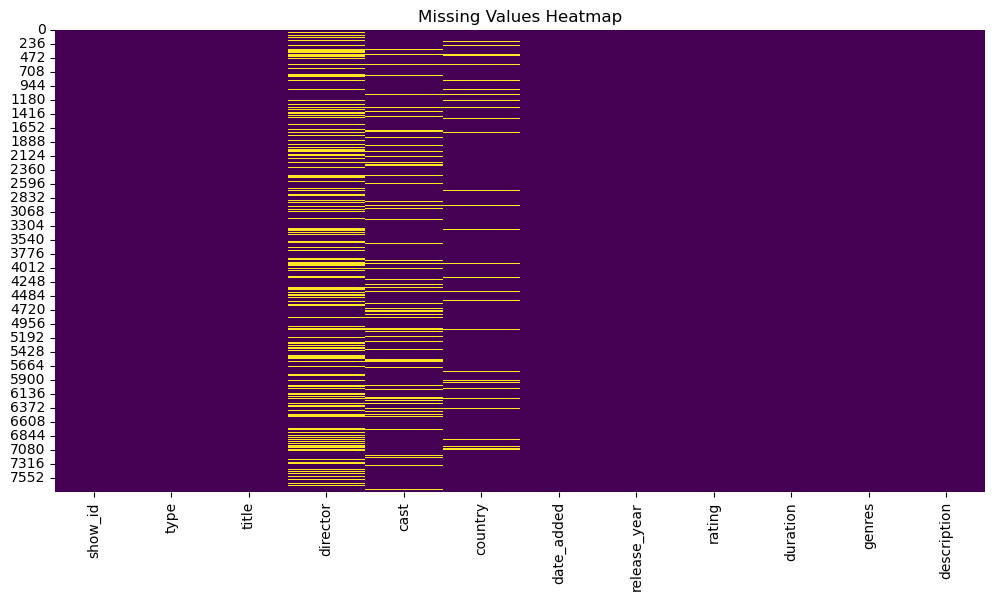

In [21]:
# Visualize Missing Values
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

In [22]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [23]:
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description


In [24]:
df.nunique()

show_id         7787
type               2
title           7787
director        4049
cast            6831
country          681
date_added      1565
release_year      73
rating            14
duration         206
genres           492
description     7769
dtype: int64

In [25]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration         int64
genres          object
description     object
dtype: object

In [26]:
df.memory_usage(deep=True)

Index               132
show_id          419391
type             425318
title            529324
director         429639
cast            1245247
country          463240
date_added       448600
release_year      62296
rating           416064
duration          62296
genres           641249
description     1807933
dtype: int64

In [27]:
df.sample(5, random_state=42)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
7324,s7591,Movie,Whindersson Nunes: Adult,Diego Pignataro,Whindersson Nunes,Brazil,15-Aug-19,2019,TV-MA,69,Stand-Up Comedy,Brazilian YouTube sensation Whindersson Nunes ...
4694,s5223,TV Show,Rita,NaN,"Mille Dinesen, Carsten Bjørnlund, Lise Baastru...",Denmark,15-Aug-20,2020,TV-MA,5,"International TV Shows, TV Comedies, TV Dramas","Independent, outspoken and adored by her stude..."
1322,s2189,Movie,FirstBorn,Nirpal Bhogal,"Antonia Thomas, Luke Norris, Thea Petrie, Eile...",United Kingdom,31-Mar-17,2016,TV-MA,90,"Horror Movies, International Movies",A young couple fights supernatural foes in an ...
5106,s5595,Movie,Si Doel the Movie 3,Rano Karno,"Rano Karno, Cornelia Agatha, Maudy Koesnaedi, ...",Indonesia,23-May-20,2020,TV-G,93,"Dramas, International Movies, Music & Musicals",Torn between reuniting with one family and lea...
101,s109,TV Show,3Below: Tales of Arcadia,NaN,"Tatiana Maslany, Diego Luna, Nick Offerman, Ni...",United States,12-Jul-19,2019,TV-Y7,2,"Kids' TV, TV Action & Adventure, TV Sci-Fi & F...","After crash-landing on Earth, two royal teen a..."


In [28]:
# Phase Summary & Key Findings
# Successfully explored the overall structure of the Netflix dataset and understood its contents before beginning the analysis.
# Identified that the dataset contains 8,807 records and 12 features, covering Movies and TV Shows across different countries, genres, ratings, and release years.
# Examined the data types of all features to determine which columns require preprocessing or data type conversion.
# Analyzed descriptive statistics to gain an initial understanding of the dataset's numerical and categorical characteristics.
# Identified missing values in multiple columns, indicating the need for data cleaning before performing further analysis.
# Checked for duplicate records to ensure the dataset's integrity and improve analysis accuracy.
# Explored the uniqueness of each feature to better understand the diversity of countries, genres, ratings, and other attributes.
# Confirmed that the dataset is comprehensive and suitable for performing detailed exploratory data analysis (EDA).
# Established a strong foundation for the next phase, where data cleaning and preprocessing will be performed to prepare the dataset for accurate analysis.

In [ ]:
# Phase 2 — Data Cleaning & Preprocessing